In [153]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from states_extract import StatesDataset
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
current = os.getcwd()
parent = os.path.dirname(current)
sys.path.append(parent)

phoneme_data = pd.read_csv('datasets/phonemes.csv')
vowels = phoneme_data['Phoneme'][phoneme_data['Type'] == 'V'].tolist()
consonants = phoneme_data['Phoneme'][phoneme_data['Type'] == 'C'].tolist()

In [154]:
states_path = "states_ds/train_states"
states_ds = StatesDataset.load(states_path)

In [155]:
states_ds.delta_state

array([[-6.4527589e-01, -2.4670033e-01,  2.1547657e-01, ...,
        -8.7040335e-01, -9.1236734e-01, -9.9083684e-02],
       [ 1.2232718e+00, -1.3190918e-01,  2.4382502e-01, ...,
        -1.3956720e-01,  2.2504461e-01, -9.7109365e-01],
       [ 1.3592941e-01,  2.3353904e-02,  1.9325542e-01, ...,
         1.3052099e+00,  1.3741612e-02,  1.2385845e-04],
       ...,
       [ 1.3100109e-01,  2.8887391e-03,  4.9579144e-04, ...,
        -9.6607214e-01,  6.9087505e-02, -7.5816196e-01],
       [-3.6327341e-01,  5.9449232e-01, -1.2340546e-03, ...,
         9.9801821e-01,  5.8196878e-01, -9.8326540e-01],
       [ 1.7902696e-01, -5.5168384e-01, -1.1199713e-04, ...,
         4.2961276e-01,  1.8978119e-04,  5.3429604e-04]],
      shape=(217229, 256), dtype=float32)

In [156]:
states_ds.delta_state.shape

(217229, 256)

In [157]:


def compute_category_similarities(ds, category1, category2, embedding_col, max_samples=1000000):
    """Compute cosine similarities between two categories of phonemes (vectorized)."""
    mask1 = ds.metadata['phoneme'].isin(category1).values
    mask2 = ds.metadata['phoneme'].isin(category2).values

    arr = getattr(ds, embedding_col)
    data1 = arr[mask1]
    data2 = arr[mask2]

    # Subsample inputs BEFORE computing pairwise matrix to avoid OOM
    n = int(np.sqrt(max_samples)) + 1
    if len(data1) > n:
        data1 = data1[np.random.choice(len(data1), n, replace=False)]
    if len(data2) > n:
        data2 = data2[np.random.choice(len(data2), n, replace=False)]
    
    sim_matrix = cosine_similarity(data1, data2)

    same_category = set(category1) == set(category2)
    if same_category:
        sims = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
    else:
        sims = sim_matrix.flatten()

    if len(sims) > max_samples:
        sims = np.random.choice(sims, size=max_samples, replace=False)

    return sims

In [158]:
sims_C_C = compute_category_similarities(states_ds, consonants, consonants, 'delta_state')
sims_C_V = compute_category_similarities(states_ds, consonants, vowels, 'delta_state')
sims_V_V = compute_category_similarities(states_ds, vowels, vowels, 'delta_state')



C-V median: -0.0434
C-C median: 0.1045
V-V median: 0.1840


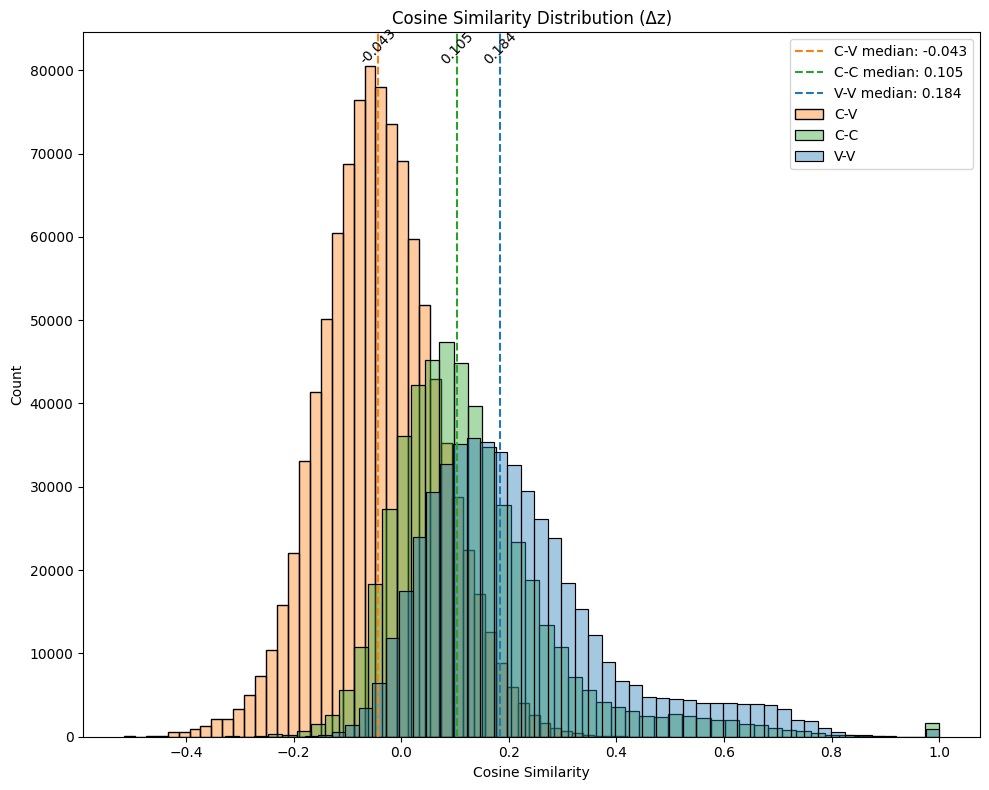

In [159]:


fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette()  # default color cycle
group_colors = {'V-V': palette[0], 'C-V': palette[1], 'C-C': palette[2]}

for sims, label in zip((sims_C_V, sims_C_C, sims_V_V), ['C-V', 'C-C', 'V-V']):
    median = np.median(sims)
    print(f"{label} median: {median:.4f}")
    color = group_colors[label]
    sns.histplot(sims, label=label, alpha=0.4, stat='count', bins=50, ax=ax, color=color)
    ax.axvline(median, linestyle='--', linewidth=1.5, color=color, label=f'{label} median: {median:.3f}')
    ax.text(median, ax.get_ylim()[1]*0.95, f'{median:.3f}', color="black",
            ha='center', va='bottom', fontsize=10,rotation=45)

ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title("Cosine Similarity Distribution (Δz)")
ax.legend()

plt.tight_layout()
plt.show()


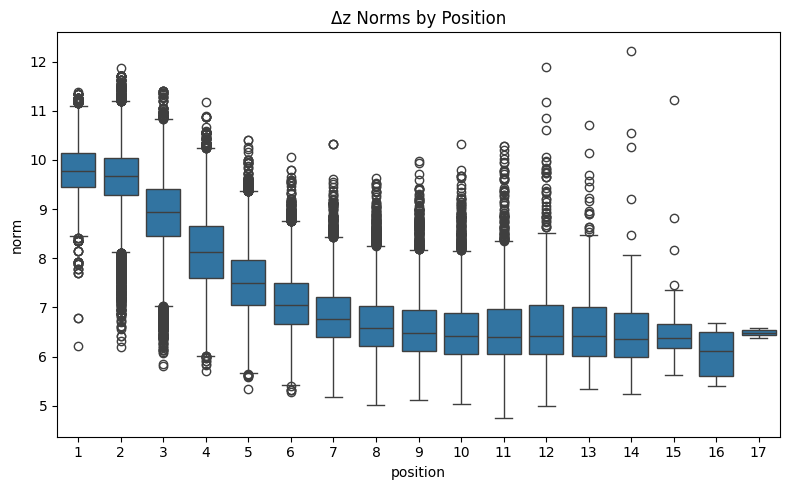

In [160]:
def norms(embeddings: np.ndarray) -> np.ndarray:
    """L2 norm of each row. Input: (N, D) → Output: (N,)"""
    return np.linalg.norm(embeddings, axis=-1) #axis=-1 means compute norm across the last dimension (D)

def norms_boxplot(dataset, embed_type="h", title="", drop_first=False):
    all_norms = norms(dataset.get_embeddings(embed_type))
    df = dataset.metadata.copy()
    df["norm"] = all_norms
    if drop_first:
        df = df[df["position"] != 0]
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(x="position", y="norm", data=df, ax=ax)
    ax.set_title(title or f"{embed_type} Norms by Position")
    plt.tight_layout()

norms_boxplot(states_ds, "delta_state", "Δz Norms by Position", drop_first=True)


In [161]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from typing import Optional
from states_extract import StateExtractor, StatesDataset
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from swp.utils.setup import seed_everything, set_device
from swp.utils.models import get_model
from swp.datasets.phonemes import get_phoneme_to_id
from ast import literal_eval
from sklearn.decomposition import PCA
from typing import Optional
import plotly.graph_objects as go
import plotly.colors as pc
from sklearn.preprocessing import StandardScaler

In [162]:
#polar trajectory
def _to_polar(pca_2d):
    """Convert 2D Cartesian to polar coordinates."""
    polar = np.zeros((len(pca_2d), 2))
    for i in range(len(pca_2d)):
        x, y = pca_2d[i, 0], -pca_2d[i, 1]
        polar[i, 0] = np.linalg.norm([x, y]) # radius 
        polar[i, 1] = np.arctan2(y, x) # angle
    return polar


def _get_edge_colorline(from_type, to_type):
    """Get color and linestyle based on phoneme type transition."""
    transitions = {
        ('C', 'C'): ('orange', '--'),
        ('C', 'V'): ('purple', '-'),
        ('V', 'C'): ('green', '--'),
        ('V', 'V'): ('blue', '-'),
        ('C', 'EOS'): ('gray', ':'),
        ('V', 'EOS'): ('gray', ':'),
    }
    return transitions.get((from_type, to_type), ('black', '-'))


def _get_color_fn(meta, word_df, color_by):
    """Get color function and legend values for a given color_by column."""
    if color_by == "phoneme_type":
        color_dict = {'V': 'blue', 'C': 'orange', 'EOS': 'gray'}
        return lambda v: color_dict.get(v, 'black'), ['V', 'C', 'EOS'], color_dict
    
    vals = meta[color_by].unique() if color_by in meta.columns else word_df[color_by].unique()
    is_numeric = pd.api.types.is_numeric_dtype(meta[color_by]) if color_by in meta.columns else False
    
    if is_numeric:
        return lambda v: plt.cm.rainbow(v / vals.max()), None, None
    
    cmap = plt.cm.Set3(np.linspace(0, 1, len(vals)))
    color_dict = {v: cmap[i] for i, v in enumerate(vals)}
    return lambda v: color_dict[v], vals, color_dict


def plot_words_trajectories(pca_2d, meta, word_df, color_by, title, drop_eos=False, save_path=None, show_phonemes=False, edge_labels=False):
    """Plot word trajectories in polar space.
    
    Args:
        pca_2d: 2D PCA embeddings
        meta: metadata DataFrame
        word_df: word properties DataFrame
        color_by: column to color by
        title: plot title
        drop_eos: skip EOS if True
        save_path: save figure to path
        show_phonemes: show phoneme labels on nodes
        edge_labels: use edge-based coloring/linestyle
    """
    meta = meta.reset_index(drop=True)
    polar = _to_polar(pca_2d)
    color_fn, legend_vals, color_dict = _get_color_fn(meta, word_df, color_by)
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    
    for word in meta["word"].unique():
        indices = np.where(meta["word"] == word)[0]
        if drop_eos is True:
            indices = np.array([i for i in indices if meta.iloc[i]["phoneme"] != '<EOS>'])
        
        # if len(indices) < 2:
        #     continue
        
        # Get word metadata
        phoneme_types = meta.iloc[indices]["phoneme_type"].values
        
        r = polar[indices, 0]
        theta = polar[indices, 1]
        
        # Determine colors and linestyles
        if not edge_labels:
            # Node-based coloring
            if color_by in meta.columns:
                colors = [color_fn(meta.iloc[i][color_by]) for i in indices]
            else:
                # color_by is in word_df
                row = word_df[word_df["Word"] == word]
                if not row.empty:
                    color = color_fn(row[color_by].values[0])
                    colors = [color] * len(r)
                else:
                    colors = ['blue'] * len(r)
            linestyles = ['-'] * len(colors)
        else:
            # Edge-based coloring
            colors = []
            linestyles = []
            for i in range(len(phoneme_types) - 1):
                color, linestyle = _get_edge_colorline(phoneme_types[i], phoneme_types[i+1])
                colors.append(color)
                linestyles.append(linestyle)
        
        # Plot trajectory
        for i in range(len(r) - 1):
            # linestyle = '--' if phoneme_types[i] == 'C' else '-'
            alpha = 0.3 + 0.7 * i / max(len(r) - 1, 1)
            ax.plot(theta[i:i+2], r[i:i+2], linestyle=linestyles[i], color=colors[i+1], lw=2, alpha=0.4)
        
        # Mark start node
        ax.scatter(theta[0], r[0], marker='o', s=5, color='green',label='Start', zorder=5)
        
        # Optional: show phoneme labels
        if show_phonemes:

            phonemes = meta.iloc[indices]["phoneme"].values
            for i in range(len(r)):
                ax.text(theta[i], r[i], phonemes[i][:2], fontsize=12, ha='center', va='center')
    
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_rticks([0, 10])
    # ax.set_title(title, fontsize=16)
    
    # Legend
    if legend_vals is not None and not edge_labels:
        handles = [plt.Line2D([0], [0], color=color_dict[v], lw=4) for v in legend_vals]
        ax.legend(handles, legend_vals, title=color_by, loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=12)
    elif edge_labels:
        # Edge-based legend
        transitions = [('C→C', 'orange', '--'), ('C→V', 'purple', '-'), ('V→C', 'green', '--'), 
                      ('V→V', 'blue', '-'), ('C→EOS', 'gray', ':'), ('V→EOS', 'gray', ':')]
        handles = [plt.Line2D([0], [0], color=t[1], linestyle=t[2], lw=4) for t in transitions]
        labels = [t[0] for t in transitions]
        ax.legend(handles, labels, title='transitions', loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=9)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

In [163]:
test_ds = StatesDataset.load("states_ds/test_states")

In [164]:
wfe = pd.read_csv("datasets/wfe_with_repetition.csv")
wfe.head()

,Unnamed: 0,Word,Condition,Lexicality,Size,Morphology,Frequency,Length,Zipf_Frequency,Phonemes,No_Stress,Part of Speech,Vowel Count,Consonant Count,can_repeat,predicted_seq
0,0,attending,RLCH,real,long,complex,0.000020,7,4.31,"['AH0', 'T', 'EH1', 'N', 'D', 'IH0', 'NG']","['AH', 'T', 'EH', 'N', 'D', 'IH', 'NG']",VERB,3,4,True,NaN
1,1,commissioner,RLCH,real,long,complex,0.000027,8,4.43,"['K', 'AH0', 'M', 'IH1', 'SH', 'AH0', 'N', 'ER0']","['K', 'AH', 'M', 'IH', 'SH', 'AH', 'N', 'ER']",NOUN,4,4,True,NaN
2,2,operation,RLCH,real,long,complex,0.000083,7,4.92,"['AA2', 'P', 'ER0', 'EY1', 'SH', 'AH0', 'N']","['AA', 'P', 'ER', 'EY', 'SH', 'AH', 'N']",NOUN,4,3,True,NaN
3,3,hospitals,RLCH,real,long,complex,0.000021,9,4.33,"['HH', 'AA1', 'S', 'P', 'IH2', 'T', 'AH0', 'L'...","['HH', 'AA', 'S', 'P', 'IH', 'T', 'AH', 'L', 'Z']",NOUN,3,6,True,NaN
4,4,acquisition,RLCH,real,long,complex,0.000018,9,4.26,"['AE2', 'K', 'W', 'AH0', 'Z', 'IH1', 'SH', 'AH...","['AE', 'K', 'W', 'AH', 'Z', 'IH', 'SH', 'AH', ...",NOUN,4,5,True,NaN


In [165]:
# length of each word in the dataset from No_stress columns (list of phonemes)
wfe["length"] = wfe["No_Stress"].apply(lambda x: len(literal_eval(x)))
wfe["length"].value_counts().sort_index()

length
3    167
4    190
5    241
7    268
8    180
9    152
Name: count, dtype: int64

In [166]:
# add cv structure like CV, CVC, CCV, etc. based on the phoneme sequence consonants and vowels and '' for tags (other)
wfe["cv_structure"] = wfe["No_Stress"].apply(lambda x: ''.join(['C' if p in consonants else 'V' if p in vowels else '' for p in literal_eval(x)]))
wfe

,Unnamed: 0,Word,Condition,Lexicality,Size,Morphology,Frequency,Length,Zipf_Frequency,Phonemes,No_Stress,Part of Speech,Vowel Count,Consonant Count,can_repeat,predicted_seq,length,cv_structure
0,0,attending,RLCH,real,long,complex,0.000020,7,4.31,"['AH0', 'T', 'EH1', 'N', 'D', 'IH0', 'NG']","['AH', 'T', 'EH', 'N', 'D', 'IH', 'NG']",VERB,3,4,True,NaN,7,VCVCCVC
1,1,commissioner,RLCH,real,long,complex,0.000027,8,4.43,"['K', 'AH0', 'M', 'IH1', 'SH', 'AH0', 'N', 'ER0']","['K', 'AH', 'M', 'IH', 'SH', 'AH', 'N', 'ER']",NOUN,4,4,True,NaN,8,CVCVCVCV
2,2,operation,RLCH,real,long,complex,0.000083,7,4.92,"['AA2', 'P', 'ER0', 'EY1', 'SH', 'AH0', 'N']","['AA', 'P', 'ER', 'EY', 'SH', 'AH', 'N']",NOUN,4,3,True,NaN,7,VCVVCVC
3,3,hospitals,RLCH,real,long,complex,0.000021,9,4.33,"['HH', 'AA1', 'S', 'P', 'IH2', 'T', 'AH0', 'L'...","['HH', 'AA', 'S', 'P', 'IH', 'T', 'AH', 'L', 'Z']",NOUN,3,6,True,NaN,9,CVCCVCVCC
4,4,acquisition,RLCH,real,long,complex,0.000018,9,4.26,"['AE2', 'K', 'W', 'AH0', 'Z', 'IH1', 'SH', 'AH...","['AE', 'K', 'W', 'AH', 'Z', 'IH', 'SH', 'AH', ...",NOUN,4,5,True,NaN,9,VCCVCVCVC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,395,haptonos,PLS,pseudo,long,simple,NaN,8,NaN,"['HH', 'AE1', 'P', 'T', 'OW0', 'N', 'OW2', 'Z']","['HH', 'AE', 'P', 'T', 'OW', 'N', 'OW', 'Z']",NaN,3,5,True,NaN,8,CVCCVCVC
1194,396,fregilis,PLS,pseudo,long,simple,NaN,8,NaN,"['F', 'R', 'EH0', 'JH', 'IH1', 'L', 'IH0', 'S']","['F', 'R', 'EH', 'JH', 'IH', 'L', 'IH', 'S']",NaN,3,5,True,NaN,8,CCVCVCVC
1195,397,regartal,PLS,pseudo,long,simple,NaN,8,NaN,"['R', 'IH0', 'G', 'AA1', 'R', 'T', 'AH0', 'L']","['R', 'IH', 'G', 'AA', 'R', 'T', 'AH', 'L']",NaN,3,5,True,NaN,8,CVCVCCVC
1196,398,sponzent,PLS,pseudo,long,simple,NaN,8,NaN,"['S', 'P', 'AA1', 'N', 'Z', 'AH0', 'N', 'T']","['S', 'P', 'AA', 'N', 'Z', 'AH', 'N', 'T']",NaN,2,6,True,NaN,8,CCVCCVCC


In [167]:
wfe[(wfe["length"] == 3) & (wfe["can_repeat"] == True)]["cv_structure"].value_counts()

cv_structure
CVC    122
VCV     16
VCC     15
CVV      7
CCV      6
VVC      1
Name: count, dtype: int64

In [176]:
# sample 1 word from each cv structure of length 4 for plotting
samples = wfe[(wfe["length"] == 4)& (wfe["Lexicality"]== 'real')].groupby("cv_structure").apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)
samples

,Unnamed: 0,Word,Condition,Lexicality,Size,Morphology,Frequency,Length,Zipf_Frequency,Phonemes,No_Stress,Part of Speech,Vowel Count,Consonant Count,can_repeat,predicted_seq,length
0,630,grain,RSSH,real,short,simple,1.510000e-05,4,4.18,"['G', 'R', 'EY1', 'N']","['G', 'R', 'EY', 'N']",NOUN,1,3,True,NaN,4
1,525,drier,RSCL,real,short,complex,1.550000e-06,4,3.19,"['D', 'R', 'AY1', 'ER0']","['D', 'R', 'AY', 'ER']",ADJ,2,2,True,NaN,4
2,715,barge,RSSL,real,short,simple,3.160000e-06,4,3.50,"['B', 'AA1', 'R', 'JH']","['B', 'AA', 'R', 'JH']",VERB,1,3,True,NaN,4
3,554,lawler,RSCL,real,short,complex,8.510000e-07,4,2.93,"['L', 'AO1', 'L', 'ER0']","['L', 'AO', 'L', 'ER']",PROPN,2,2,True,NaN,4
4,440,going,RSCH,real,short,complex,8.710000e-04,4,5.94,"['G', 'OW1', 'IH0', 'NG']","['G', 'OW', 'IH', 'NG']",VERB,2,2,True,NaN,4
5,505,eyebrow,RSCL,real,short,complex,2.340000e-06,4,3.37,"['AY1', 'B', 'R', 'AW2']","['AY', 'B', 'R', 'AW']",NOUN,2,2,True,NaN,4
6,768,aloof,RSSL,real,short,simple,9.770000e-07,4,2.99,"['AH0', 'L', 'UW1', 'F']","['AH', 'L', 'UW', 'F']",ADJ,2,2,True,NaN,4
7,744,ikea,RSSL,real,short,simple,3.090000e-06,4,3.49,"['AY2', 'K', 'IY1', 'AH0']","['AY', 'K', 'IY', 'AH']",PROPN,3,1,True,NaN,4


In [172]:
pca = PCA(n_components=2)
state_pca = pca.fit_transform(StandardScaler().fit_transform(test_ds.state))

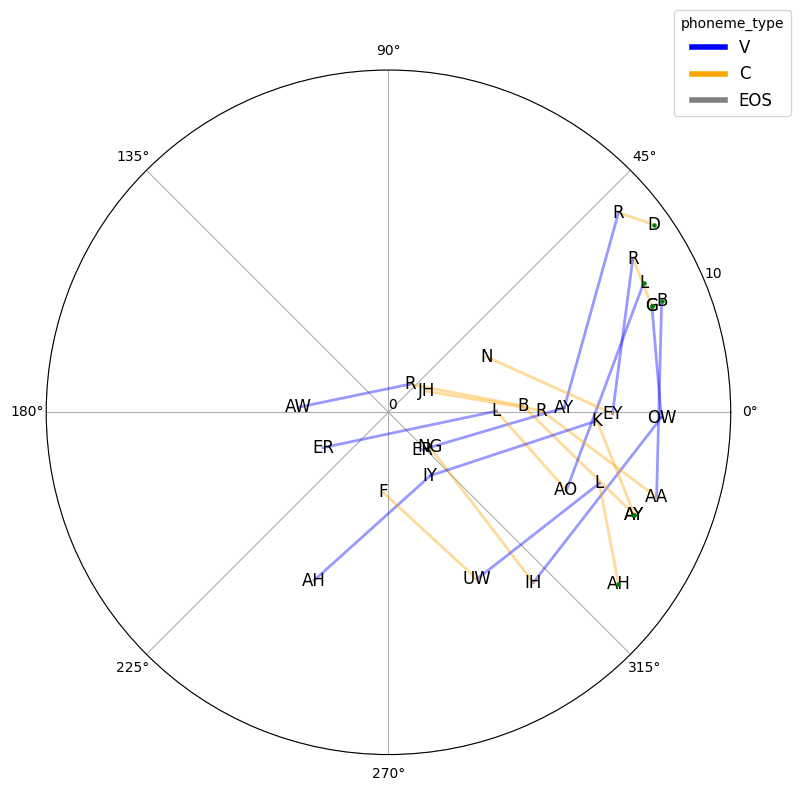

In [177]:
# words = ['eyeing', 'gray', 'liar', 'elk', 'odor', 'bar']
words = samples["Word"].tolist()
words_meta = test_ds.metadata[test_ds.metadata["word"].isin(words)]
words_mask = test_ds.metadata["word"].isin(words)
pcas = state_pca[words_mask]
filtered_wfe = wfe[wfe["Word"].isin(words)]

plot_words_trajectories(pcas, words_meta, filtered_wfe, color_by="phoneme_type",
                        show_phonemes=True,
                        drop_eos=True,
                        title="Word Trajectories in PCA Space (z) - different cv patterns")

In [74]:
test_ds.metadata

,seq_id,word,position,phoneme,phoneme_type
0,0,attending,0,AH,V
1,0,attending,1,T,C
2,0,attending,2,EH,V
3,0,attending,3,N,C
4,0,attending,4,D,C
...,...,...,...,...,...
8343,1197,pashibled,4,B,C
8344,1197,pashibled,5,AH,V
8345,1197,pashibled,6,L,C
8346,1197,pashibled,7,D,C


In [ ]:
words = wfe[(wfe["length"]==3)& (wfe["can_repeat"]==True)]["Word"].tolist()




In [54]:
from swp.utils.datasets import get_train_dataset
train_df = get_train_dataset()
train_df["length"] = train_df["No_Stress"].apply(lambda x: len(x))
train_df["cv_structure"] = train_df["No_Stress"].apply(
    lambda x: ''.join(['C' if p in consonants else 'V' if p in vowels else '' for p in x])
)
train_df.head() 

,Word,Frequency,Zipf_Frequency,Part_of_Speech,Phonemes,No_Stress,length,cv_structure
0,the,0.0537,7.73,PRON,"[DH, AH0]","[DH, AH]",2,CV
1,to,0.0269,7.43,PART,"[T, UW1]","[T, UW]",2,CV
2,and,0.0257,7.41,CCONJ,"[AH0, N, D]","[AH, N, D]",3,VCC
3,of,0.0251,7.40,ADP,"[AH1, V]","[AH, V]",2,VC
4,a,0.0229,7.36,PRON,[AH0],[AH],1,V


In [55]:
train_df[train_df["length"] == 3]["cv_structure"].value_counts()

cv_structure
CVC    1861
VCV     136
CCV     117
VCC     100
CVV      92
VVC      16
VVV       1
Name: count, dtype: int64

In [57]:
words = train_df[(train_df["length"]==3)]["Word"].tolist()

In [56]:
train_ds = StatesDataset.load("states_ds/train_states")

In [58]:
train_ds.metadata

,seq_id,word,position,phoneme,phoneme_type
0,0,the,0,DH,C
1,0,the,1,AH,V
2,0,the,2,<EOS>,EOS
3,1,to,0,T,C
4,1,to,1,UW,V
...,...,...,...,...,...
217224,29999,dislocation,6,EY,V
217225,29999,dislocation,7,SH,C
217226,29999,dislocation,8,AH,V
217227,29999,dislocation,9,N,C


In [60]:
# get final state for each word in the test dataset before <EOS> one before max position
words_mask = train_ds.metadata["word"].isin(words) & (train_ds.metadata["position"] == train_ds.metadata.groupby("word")["position"].transform("max") - 1)
words_final_states = train_ds.state[words_mask]
pca = PCA(n_components=2)
final_states_pca = pca.fit_transform(words_final_states)

In [64]:
ssp_ds = StatesDataset.load("states_ds/ssp_states")
ssp_ds.metadata.head()

,seq_id,word,position,phoneme
0,0,CCV,0,P
1,0,CCV,1,T
2,0,CCV,2,AH
3,0,CCV,3,<EOS>
4,1,VCC,0,AH


In [68]:
ssp_ds.metadata["word"].value_counts()

word
CCV    33120
VCC    33120
Name: count, dtype: int64

In [65]:
mask = (ssp_ds.metadata["position"] == ssp_ds.metadata.groupby("seq_id")["position"].transform("max") - 1)
words_final_states_ssp = ssp_ds.state[mask]
pca_ssp = PCA(n_components=2)
final_states_pca_ssp = pca_ssp.fit_transform(words_final_states_ssp)

16560

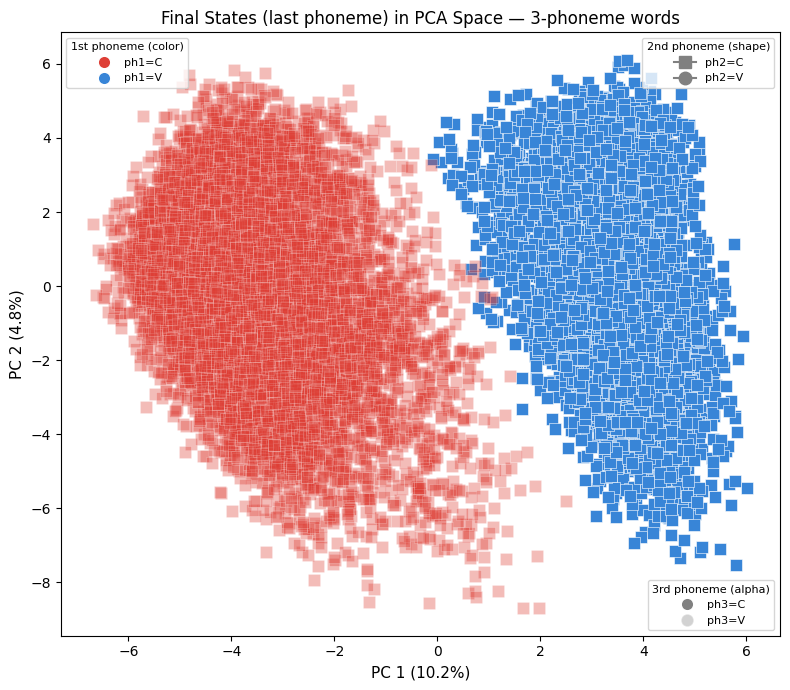

In [69]:
# Color = 1st phoneme, Marker = 2nd phoneme, Intensity (alpha) = 3rd phoneme

mask = (ssp_ds.metadata["position"] == ssp_ds.metadata.groupby("seq_id")["position"].transform("max") - 1)
words_final_states_ssp = ssp_ds.state[mask]
pca_ssp = PCA(n_components=2)
final_states_pca_ssp = pca_ssp.fit_transform(words_final_states_ssp)

# Per-point metadata, same mask → same order as final_states_pca_ssp
eos_meta = ssp_ds.metadata[mask].reset_index(drop=True)
eos_meta["ph1"] = eos_meta["word"].str[0]   # word is the CV-structure, e.g. "CCV"
eos_meta["ph2"] = eos_meta["word"].str[1]
eos_meta["ph3"] = eos_meta["word"].str[2]

color_map  = {'C': "#DE3F36", 'V': "#3885D7"}   # color     → 1st phoneme
marker_map = {'C': 's',       'V': 'o'}          # shape     → 2nd phoneme
alpha_map  = {'C': 1.0,       'V': 0.35}         # intensity → 3rd phoneme

POINT_SIZE = 80   # same size for all markers

fig, ax = plt.subplots(figsize=(8, 7))

for ph3, alpha in alpha_map.items():
    for ph2, marker in marker_map.items():
        for ph1, color in color_map.items():
            mask_pt = (eos_meta["ph1"] == ph1) & (eos_meta["ph2"] == ph2) & (eos_meta["ph3"] == ph3)
            if mask_pt.sum() == 0:
                continue
            ax.scatter(
                final_states_pca_ssp[mask_pt.values, 0], final_states_pca_ssp[mask_pt.values, 1],
                c=color, s=POINT_SIZE, marker=marker, alpha=alpha, edgecolors='white', linewidths=0.4,
                label=f"{ph1}{ph2}{ph3}"
            )

ax.set_xlabel(f"PC 1 ({pca_ssp.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC 2 ({pca_ssp.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title("Final States (last phoneme) in PCA Space — 3-phoneme words", fontsize=12)

# Three separate legend panels
from matplotlib.lines import Line2D
legend_color  = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=9, label=f"ph1={t}") for t,c in color_map.items()]
legend_marker = [Line2D([0],[0], marker=m, color='gray', markersize=9, label=f"ph2={t}") for t,m in marker_map.items()]
legend_alpha  = [Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=9, alpha=a, label=f"ph3={t}") for t,a in alpha_map.items()]

l1 = ax.legend(handles=legend_color,  title="1st phoneme (color)",  loc="upper left",  fontsize=8, title_fontsize=8)
l2 = ax.legend(handles=legend_marker, title="2nd phoneme (shape)",  loc="upper right", fontsize=8, title_fontsize=8)
l3 = ax.legend(handles=legend_alpha,  title="3rd phoneme (alpha)",  loc="lower right", fontsize=8, title_fontsize=8)
ax.add_artist(l1)
ax.add_artist(l2)

plt.tight_layout()
plt.show()


In [117]:
lr8_params = np.load("results/final_grid_search/source-modified-low_rank-8-state_concat-init_delta_state_mean/scale_params.npz", allow_pickle=True)
per_pos_params = np.load("results/final_grid_search_compare_methods/source-modified-per_pos-state_concat-init_delta_state_mean/scale_params.npz", allow_pickle=True)
onion_params = np.load("results/final_grid_search_compare_methods/source-modified-onion-state_concat-init_delta_state_mean/scale_params.npz", allow_pickle=True)
spiral_params = np.load("results/final_grid_search_compare_methods/source-modified-spiral_rope-state_concat-init_delta_state_mean/scale_params.npz", allow_pickle=True)

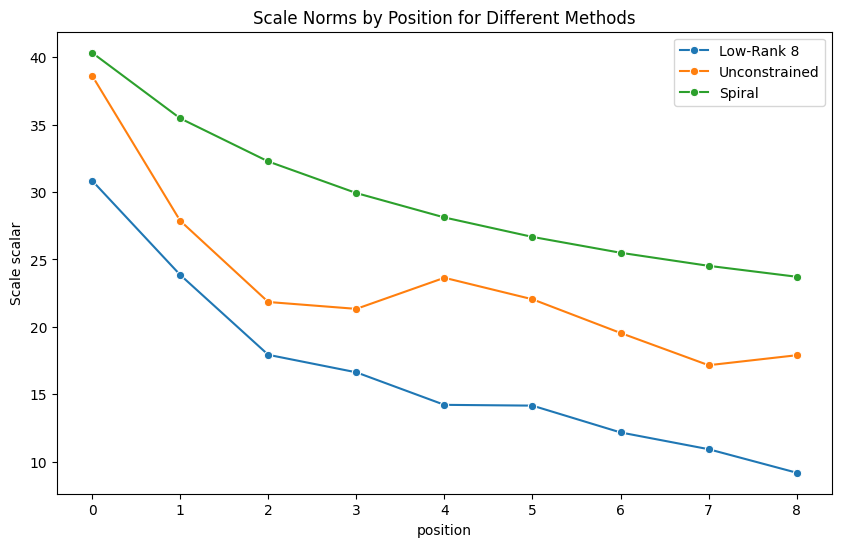

In [267]:
# plot of norms of scales for all methods with legend
plt.figure(figsize=(10, 6))
sns.lineplot(data=np.linalg.norm(lr8_params["scales"][:9], axis=1), label="Low-Rank 8", marker='o')
sns.lineplot(data=np.linalg.norm(per_pos_params["scales"][:9], axis=1), label="Unconstrained", marker='o')
# sns.lineplot(data=np.linalg.norm(onion_params["scales"][:9], axis=1), label="Onion", marker='o')
sns.lineplot(data=np.linalg.norm(spiral_params["scales"][:9], axis=1), label="Spiral", marker='o')
plt.title("Scale Norms by Position for Different Methods")
plt.xlabel("position")
plt.ylabel("Scale scalar")
# plt.ylim(0, 100)
plt.legend()
plt.show()

In [122]:
lr8_params = np.load("results/final_grid_search/source-modified-low_rank-8-state_concat-init_delta_state_mean-train_embed/scale_params.npz", allow_pickle=True)

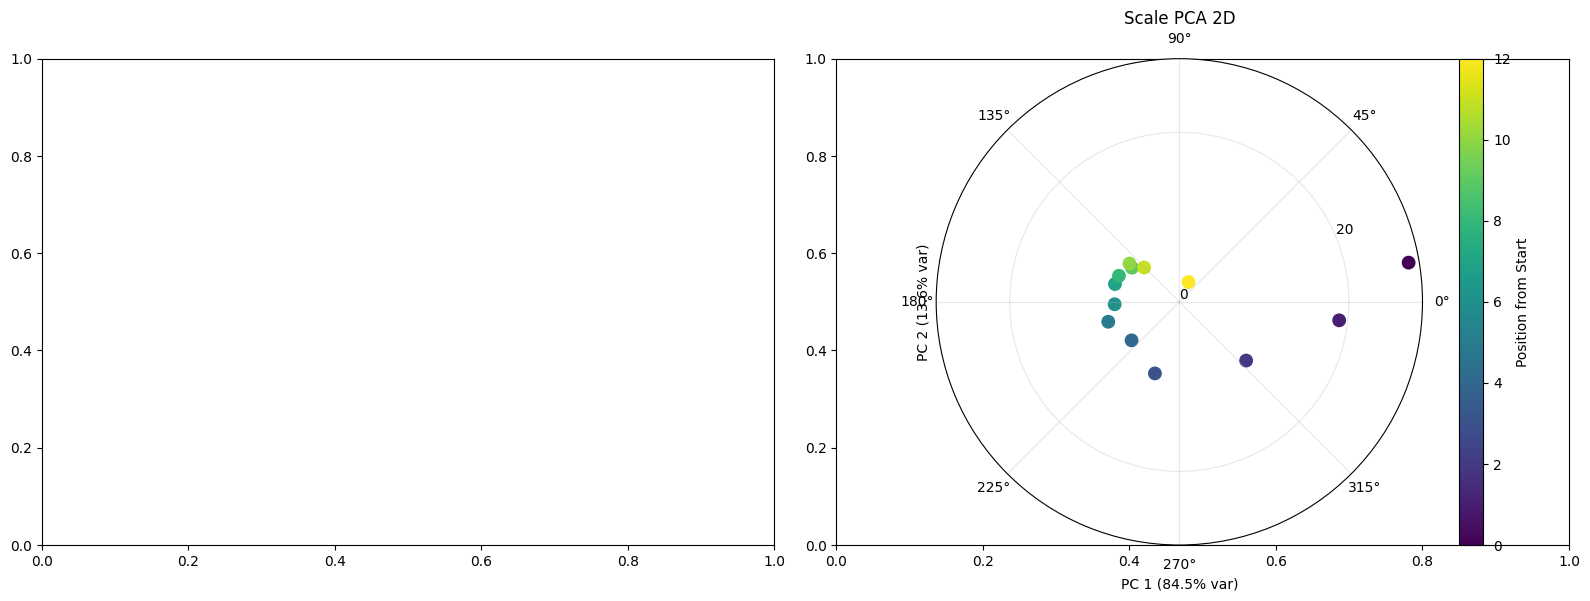

In [123]:
# polar plot for pca of scales for low-rank 8
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
scales_2d = pca.fit_transform(lr8_params["scales"][:13])
colors = np.arange(scales_2d.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# sns.scatterplot(x=scales_2d[:, 0], y=scales_2d[:, 1], hue=colors, palette="viridis", legend=False, s=80, ax=axes[0])
# axes[0].set(xlabel=f"PC 1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)", ylabel=f"PC 2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)", title="Scale PCA 2D")
# axes[0].grid(alpha=0.3)

ax2 = fig.add_subplot(1, 2, 2, projection="polar")
angles = np.arctan2(scales_2d[:, 1], scales_2d[:, 0])
r = np.linalg.norm(scales_2d, axis=1)
scatter = ax2.scatter(angles, r, c=colors, cmap="viridis", s=80)
fig.colorbar(scatter, ax=ax2, label="Position from Start", orientation="vertical")
ax2.set_title("Scale PCA Polar")
ax2.set(xlabel=f"PC 1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)", ylabel=f"PC 2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)", title="Scale PCA 2D")
ax2.set_rticks([0, 20])
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

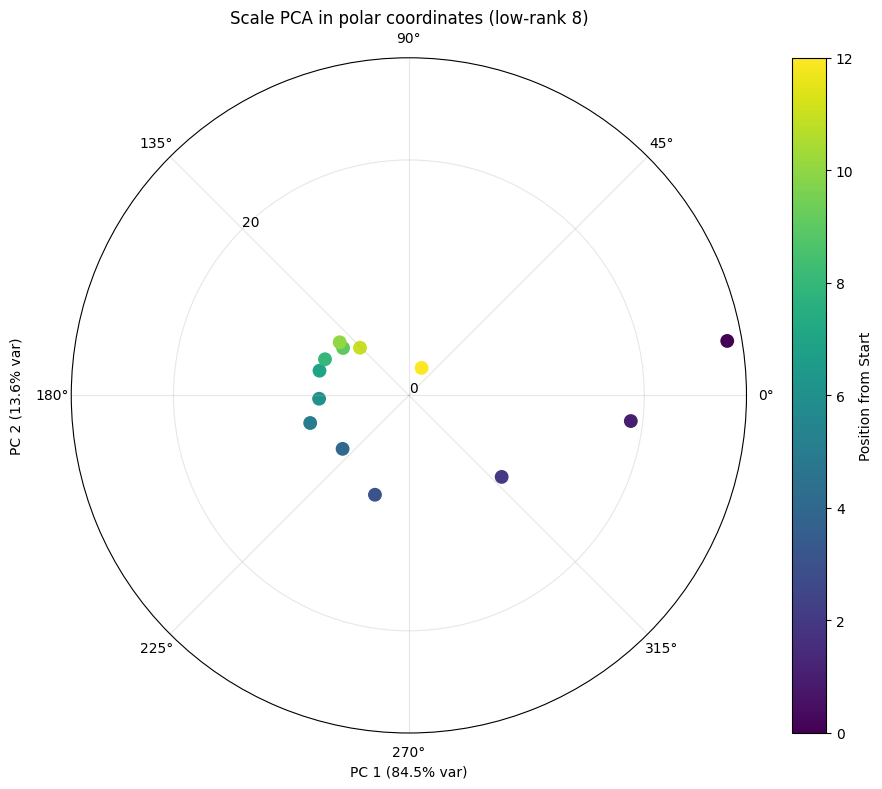

In [124]:
# polar plot for pca of scales for low-rank 8
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
scales_2d = pca.fit_transform(lr8_params["scales"][:13])
colors = np.arange(scales_2d.shape[0])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="polar")
angles = np.arctan2(scales_2d[:, 1], scales_2d[:, 0])
r = np.linalg.norm(scales_2d, axis=1)
scatter = ax.scatter(angles, r, c=colors, cmap="viridis", s=80)
fig.colorbar(scatter, ax=ax, label="Position from Start", orientation="vertical")
ax.set_title("Scale PCA in polar coordinates (low-rank 8)")
ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
ax.set_rlabel_position(135)          # rotate the 0/10 radius ticks away from the label
ax.yaxis.set_label_coords(-0.07, 0.5) # push the ylabel further left

ax.set_rticks([0, 20])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [125]:
df_lr8_train = pd.read_csv("results/final_grid_search_repeat_only/source-modified-low_rank-8-state_concat-init_delta_state_mean-train_embed/merged_predictions.csv")
df_lr8_no_train = pd.read_csv("results/final_grid_search_repeat_only/source-modified-low_rank-8-state_concat-init_delta_state_mean/merged_predictions.csv")
df_onion_no_train = pd.read_csv("results/final_grid_search_repeat_only/source-modified-onion-state_concat-init_delta_state_mean/merged_predictions.csv")
df_onion_train = pd.read_csv("results/final_grid_search_repeat_only/source-modified-onion-state_concat-init_delta_state_mean-train_embed/merged_predictions.csv")
df_spiral_no_train = pd.read_csv("results/final_grid_search_repeat_only/source-modified-spiral_rope-state_concat-init_delta_state_mean/merged_predictions.csv")
df_spiral_train = pd.read_csv("results/final_grid_search_repeat_only/source-modified-spiral_rope-state_concat-init_delta_state_mean-train_embed/merged_predictions.csv")
df_per_pos_no_train = pd.read_csv("results/final_grid_search_repeat_only/source-modified-per_pos-state_concat-init_delta_state_mean/merged_predictions.csv")
df_per_pos_train = pd.read_csv("results/final_grid_search_repeat_only/source-modified-per_pos-state_concat-init_delta_state_mean-train_embed/merged_predictions.csv")

In [204]:
import pandas as pd

# 1. Combine your dataframes into a single one with Method and Train_Embed columns
dfs = [
    (df_lr8_train, "Low-Rank 8", True),
    (df_lr8_no_train, "Low-Rank 8", False),
    (df_onion_train, "Onion", True),
    (df_onion_no_train, "Onion", False),
    (df_spiral_train, "Spiral", True),
    (df_spiral_no_train, "Spiral", False),
    # (df_per_pos_train, "look-up", True),
    # (df_per_pos_no_train, "look-up", False)
]

all_dfs = []
for df, method, is_train in dfs:
    df = df.copy()
    df["Method"] = method
    df["Train_Embed"] = is_train
    all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True)

In [184]:
def _coerce_match(series: pd.Series) -> pd.Series:
    if series.dtype == object:
        return pd.to_numeric(
            series.astype(str).str.strip().str.lower().map({"true": 1, "false": 0}),
            errors="coerce",
        )
    return pd.to_numeric(series, errors="coerce")

In [197]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import pandas as pd

def plot_feature_accuracy(df: pd.DataFrame, feature: str, save_dir: str | Path = None, title_suffix: str = "") -> None:
    if feature not in df.columns:
        print(f"Feature '{feature}' not found.")
        return

    df = df.copy()
    if "match" in df.columns:
        df["match"] = _coerce_match(df["match"])

    # Setup grouping and colors
    df['HueGroup'] = df['Method'] + '_' + df['Train_Embed'].astype(str)
    methods = df['Method'].dropna().unique()
    colors = sns.color_palette("tab10", len(methods))
    
    palette = {f"{m}_{t}": c for m, c in zip(methods, colors) for t in (True, False)}
    hue_order = [f"{m}_{t}" for m in methods for t in (True, False)]

    summary = df.groupby([feature, "Method", "Train_Embed", "HueGroup"])["match"].mean().reset_index()

    # Create Plot (Increased width to 14 to make bars wider)
    plt.figure(figsize=(12, 6))
    
    # We pass width=0.85 to slightly minimize gaps between bars (supported in seaborn >= 0.13.0)
    ax = sns.barplot(
        data=summary, x=feature, y="match", 
        hue="HueGroup", palette=palette, hue_order=hue_order,
        width=0.85
    )

    # Decorate bars (annotations + shading for Train_Embed == False)
    labels = ax.get_legend_handles_labels()[1]
    num_cats = len(summary[feature].unique())
    
    for i, bar in enumerate(ax.patches):
        height = bar.get_height()
        if pd.isna(height) or height <= 0: continue
        
        # Add shading if it's a "False" (no train embed) bar
        if (i // num_cats) < len(labels) and "_False" in labels[i // num_cats]:
            bar.set(alpha=0.4, hatch='///', edgecolor="white")
            
        # Add accuracy text
        ax.annotate(f"{height:.2f}", (bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 2), 
                    textcoords='offset points', rotation=90)

    # Custom Legend (Inside plot, split into 2 columns to save height)
    legend_elements = [Patch(facecolor=c, label=m) for c, m in zip(colors, methods)] + [
        Patch(facecolor='white', label=''), 
        Patch(facecolor='gray', label='Train Embed: True'),
        Patch(facecolor='gray', alpha=0.4, hatch='///', edgecolor='white', label='Train Embed: False')
    ]
    ax.legend(handles=legend_elements, title="Method & Setup", loc='upper right', ncol=2)

    # Formatting and saving
    ax.set(ylim=(0, 1.25), xlabel=feature, ylabel="Accuracy", 
           title=f"Accuracy by {feature}" + (f" - {title_suffix}" if title_suffix else ""))
    
    if df[feature].dtype == object or str(df[feature].dtype) == "category":
        ax.tick_params(axis="x", rotation=45)
        
    plt.tight_layout()
    if save_dir:
        path = Path(save_dir) / f"accuracy_by_{feature}.png"
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, bbox_inches="tight")
        
    plt.show()

In [260]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import pandas as pd

def plot_method_split(df: pd.DataFrame, split_by: str = "Lexicality", save_dir: str | Path = None, title_suffix: str = "") -> None:
    if split_by not in df.columns: return
    
    df = df.copy()
    if "match" in df.columns: df["match"] = _coerce_match(df["match"])

    methods = df['Method'].dropna().unique()
    opts = sorted(df[split_by].dropna().unique(), key=lambda x: str(x).lower() == "long")
    colors = dict(zip(methods, sns.color_palette("tab10", len(methods))))

    plt.figure(figsize=(6, 6))
    
    # 1. Base seaborn plot
    ax = sns.barplot(
        data=df.groupby(["Method", split_by])["match"].mean().reset_index(),
        x="Method", y="match", hue=split_by, hue_order=opts, order=methods, edgecolor="white"
    )

    # 2. Iterate patches to set Method=Color, Hue=Pattern natively
    for i, bar in enumerate(ax.patches):
        if pd.isna(bar.get_height()): continue
        
        bar.set_facecolor(colors[methods[i % len(methods)]])
        
        # Second category (e.g. Pseudo) gets a clean, native cross-hatch with slight transparency
        if i // len(methods) > 0: 
            bar.set_hatch('//')
            bar.set_alpha(0.7)
            
        if bar.get_height() > 0:
            ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points', rotation=90)

    # 3. Native Legend guaranteed inside the plot bounds
    handles = [Patch(facecolor=colors[m], label=m) for m in methods] + [Patch(color='none', label='')]
    for i, opt in enumerate(opts):
        handles.append(Patch(facecolor='gray', hatch='//' if i>0 else '', alpha=0.7 if i>0 else 1.0, label=str(opt).title()))
        
    ax.legend(handles=handles, title=f"Method & {split_by}", loc='best', ncol=2)
    ax.set(ylim=(0, 1.1), title=f"Method Accuracy Split by {split_by} " + (f"- {title_suffix}" if title_suffix else ""))
    
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    ax.set_ylabel("Accuracy")
    if save_dir:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        plt.savefig(Path(save_dir) / f"split_{split_by}.png", bbox_inches="tight")
        
    plt.show()

# Example Usage:
# plot_method_split(merged_df[merged_df["Train_Embed"] == True], split_by="Lexicality", save_dir="plots/conditions_results", title_suffix="Train Embed Only")

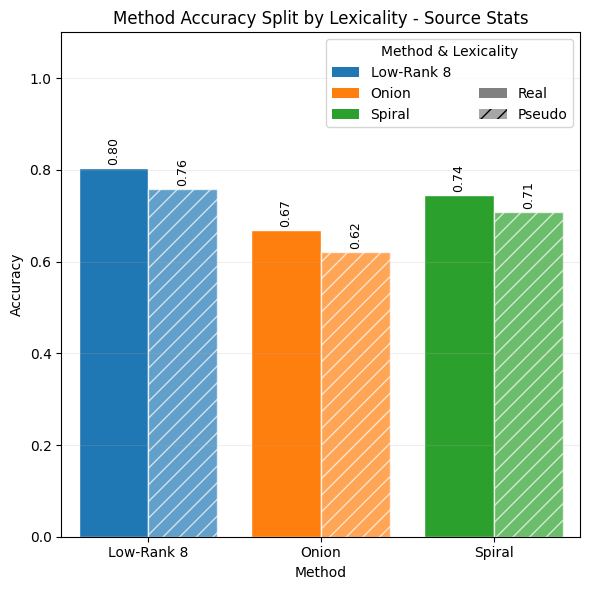

In [261]:
plot_method_split(merged_df[merged_df["Train_Embed"] == True], split_by="Lexicality", save_dir="plots/conditions_results", title_suffix="Source Stats")

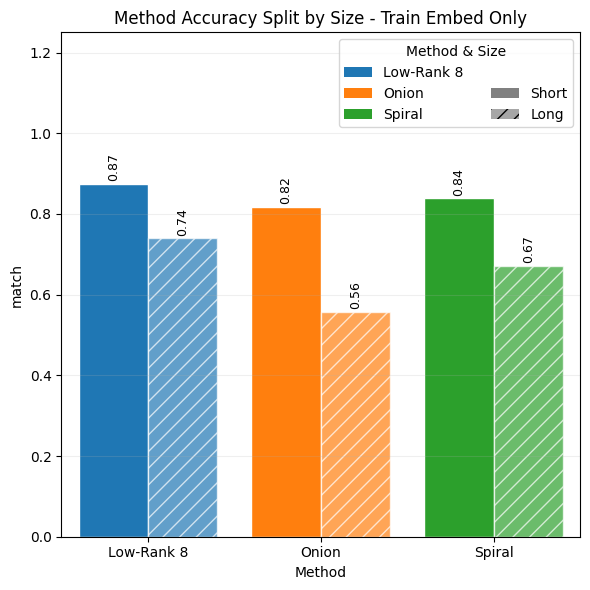

In [221]:
plot_method_split(merged_df[merged_df["Train_Embed"] == True], split_by="Size", save_dir="plots/conditions_results", title_suffix="Train Embed Only")

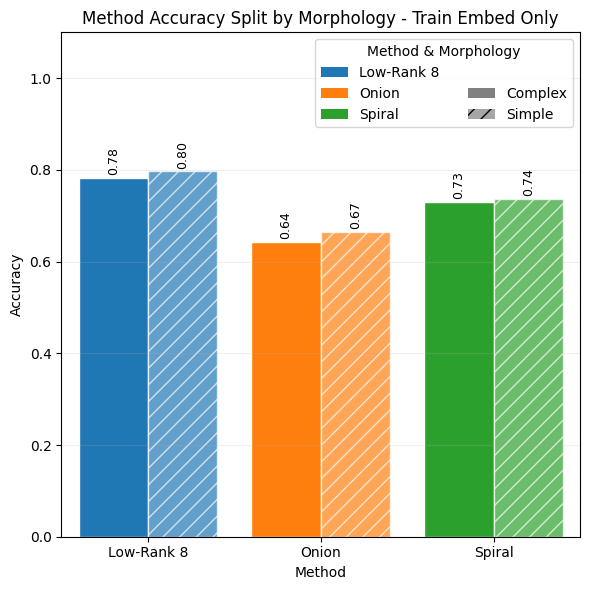

In [263]:
plot_method_split(merged_df[merged_df["Train_Embed"] == True], split_by="Morphology", save_dir="plots/conditions_results", title_suffix="Train Embed Only")

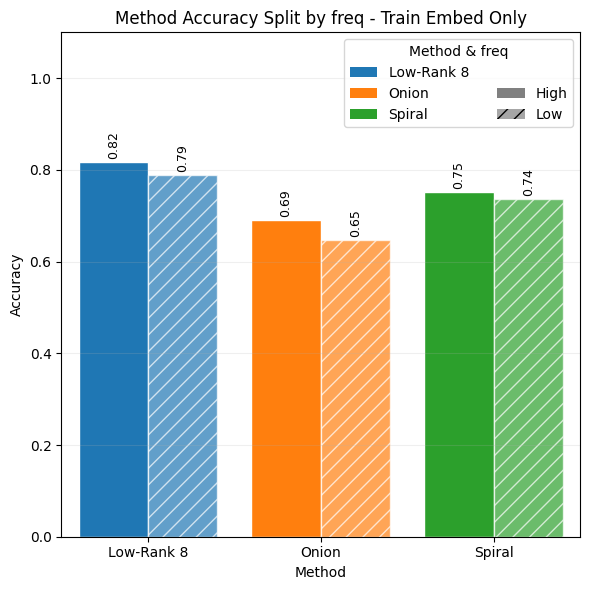

In [266]:
plot_method_split(merged_df[merged_df["Train_Embed"] == True], split_by="freq", save_dir="plots/conditions_results", title_suffix="Train Embed Only")

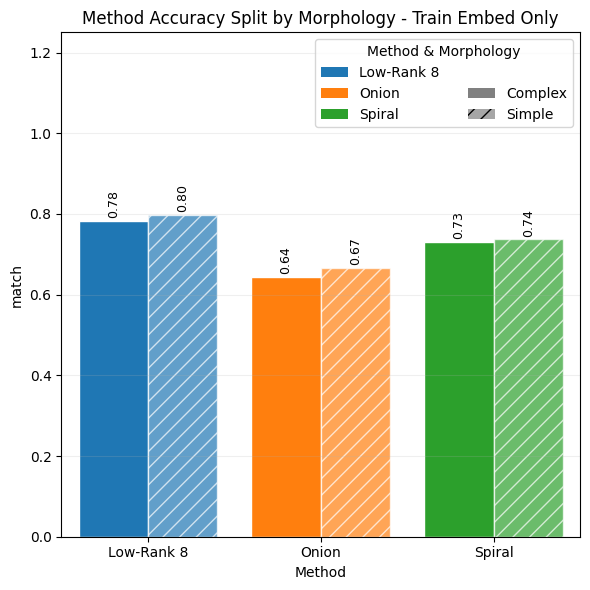

In [219]:
plot_method_split(merged_df[merged_df["Train_Embed"] == True], split_by="Morphology", save_dir="plots/conditions_results", title_suffix="Train Embed Only")

In [217]:
# add freq columns based on condition for real words the second character of the condition column is the frequency of the word, add a new column "freq" to the merged_df based on the second character of the condition column for real words, and set it to NaN for non-real words
# L -> low, H-> high, example: RLCH -> low freq
merged_df["freq"] = merged_df.apply(lambda row: row["Condition"][3] if row["Lexicality"] == "real" else None, axis=1)
merged_df["freq"] = merged_df["freq"].map({"L": "low", "H": "high", None: None})
merged_df["freq"].value_counts(dropna=False)

freq
high    13764
low     13368
NaN     12456
Name: count, dtype: int64

In [145]:


train_ds.delta_state.shape

(217229, 256)

Positions: 100%|██████████| 10/10 [00:01<00:00,  8.75it/s]


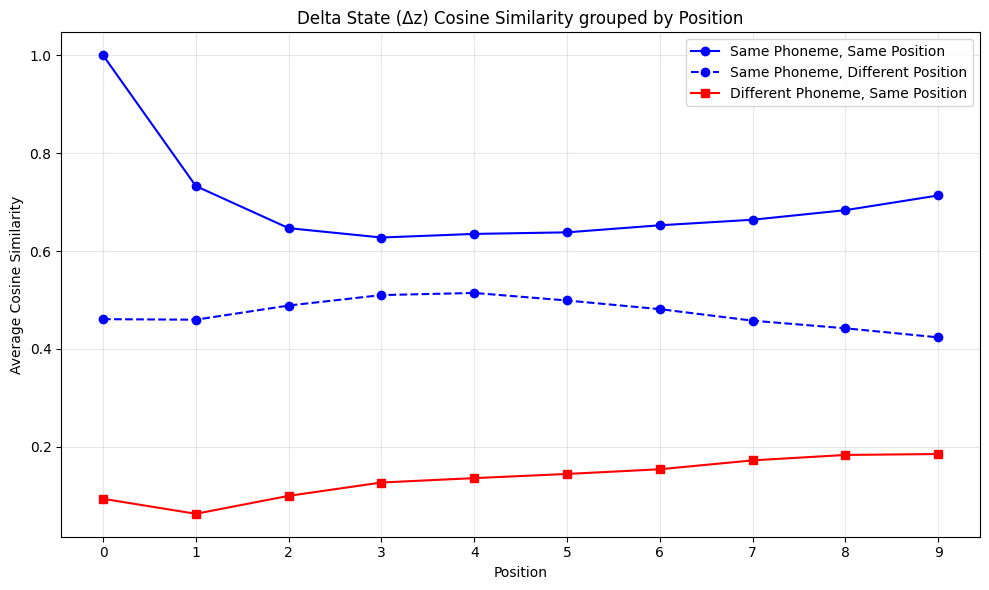

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

def plot_delta_z_similarity(dataset, state_col='delta_state', max_samples=200):
    """
    Computes and plots cosine similarities for delta states.
    Limits samples to avoid Out-Of-Memory (OOM) errors.
    """
    metadata = dataset.metadata.copy()
    states = getattr(dataset, state_col)
    
    positions = range(0,10)
    phonemes = metadata['phoneme'].unique()
    
    # Subsample indices for each (phoneme, position) to save memory
    np.random.seed(42)
    idx_dict = {}
    
    groups = metadata.groupby(['phoneme', 'position'])
    for (ph, p), group in groups:
        idx = group.index.values
        if len(idx) > max_samples:
            idx = np.random.choice(idx, max_samples, replace=False)
        idx_dict[(ph, p)] = idx

    spsp_means = []  # Same Phoneme, Same Position
    spdp_means = []  # Same Phoneme, Different Position
    dpsp_means = []  # Different Phoneme, Same Position
    
    for p in tqdm(positions, desc="Positions"):
        # 1. Same phoneme, same position
        sims_spsp = []
        for ph in phonemes:
            idx = idx_dict.get((ph, p), [])
            if len(idx) > 1:
                sim = cosine_similarity(states[idx])
                triu_idx = np.triu_indices_from(sim, k=1)
                if len(triu_idx[0]) > 0:
                    sims_spsp.append(sim[triu_idx].mean())
        spsp_means.append(np.nanmean(sims_spsp) if sims_spsp else np.nan)
        
        # 2. Same phoneme, different position
        sims_spdp = []
        for ph in phonemes:
            idx_p = idx_dict.get((ph, p), [])
            idx_not_p = []
            for other_p in positions:
                if other_p != p:
                    idx_not_p.extend(idx_dict.get((ph, other_p), []))
            
            if len(idx_p) > 0 and len(idx_not_p) > 0:
                sim = cosine_similarity(states[idx_p], states[idx_not_p])
                sims_spdp.append(sim.mean())
        spdp_means.append(np.nanmean(sims_spdp) if sims_spdp else np.nan)
        
        # 3. Different phoneme, same position
        all_idx_p = []
        all_ph_p = []
        for ph in phonemes:
            idx = idx_dict.get((ph, p), [])
            all_idx_p.extend(idx)
            all_ph_p.extend([ph] * len(idx))
            
        all_idx_p = np.array(all_idx_p)
        all_ph_p = np.array(all_ph_p)
        
        if len(all_idx_p) > 1:
            # Further downsample if position cluster is huge
            if len(all_idx_p) > 2000:
                sub_idx = np.random.choice(len(all_idx_p), 2000, replace=False)
                all_idx_p = all_idx_p[sub_idx]
                all_ph_p = all_ph_p[sub_idx]
                
            sim = cosine_similarity(states[all_idx_p])
            
            # Mask to find different phonemes (excluding self vs self)
            ph_mat1 = np.expand_dims(all_ph_p, 1)
            ph_mat2 = np.expand_dims(all_ph_p, 0)
            diff_ph_mask = (ph_mat1 != ph_mat2)
            
            # Upper triangle
            triu_mask = np.triu(np.ones_like(diff_ph_mask, dtype=bool), k=1)
            final_mask = diff_ph_mask & triu_mask
            
            sims_dpsp = sim[final_mask]
            
            if len(sims_dpsp) > 0:
                dpsp_means.append(sims_dpsp.mean())
            else:
                dpsp_means.append(np.nan)
        else:
            dpsp_means.append(np.nan)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(positions, spsp_means, color='blue', linestyle='-', marker='o', label='Same Phoneme, Same Position')
    plt.plot(positions, spdp_means, color='blue', linestyle='--', marker='o', label='Same Phoneme, Different Position')
    plt.plot(positions, dpsp_means, color='red', linestyle='-', marker='s', label='Different Phoneme, Same Position')

    plt.xlabel('Position')
    plt.ylabel('Average Cosine Similarity')
    plt.title('Delta State (Δz) Cosine Similarity grouped by Position')
    plt.xticks(positions)
    plt.legend()
    plt.grid(axis='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the function on your dataset
plot_delta_z_similarity(train_ds, state_col='delta_state', max_samples=200)

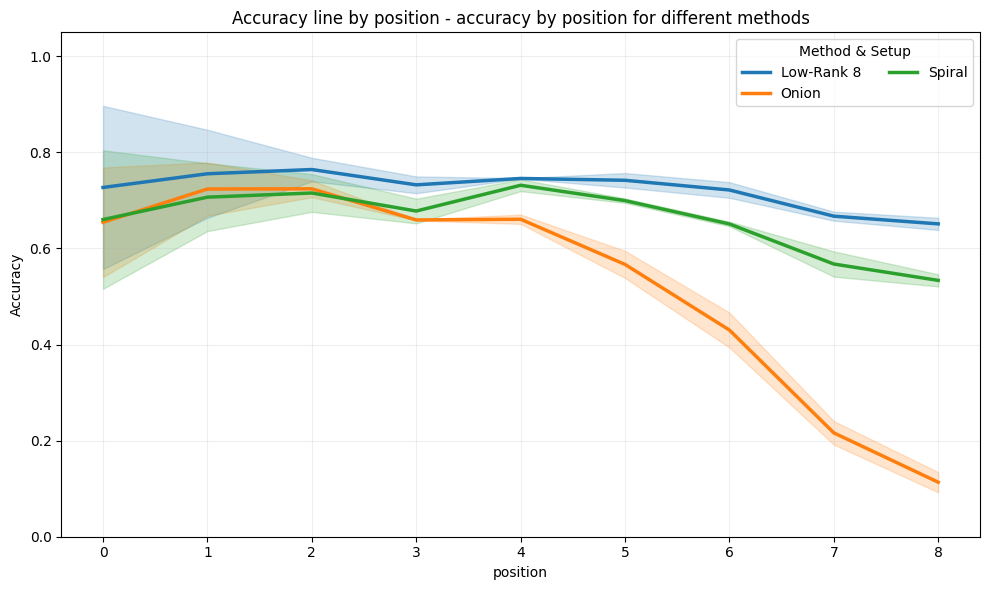

In [205]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_accuracy_line(df: pd.DataFrame, feature: str, save_dir: str | Path = None, title_suffix: str = "") -> None:
    if feature not in df.columns:
        print(f"Feature '{feature}' not found in dataframe.")
        return

    df = df.copy()
    if "match" in df.columns:
        df["match"] = _coerce_match(df["match"])

    # Aggregate accuracy
    summary = df.groupby([feature, "Method", "Train_Embed"])["match"].mean().reset_index()

    # Create the Plot
    plt.figure(figsize=(10, 6))
    
    # Plot lines: Hue -> Method, Style -> Train_Embed
    # dashes dictionary maps the boolean True/False to line styles
    ax = sns.lineplot(
        data=summary,
        x=feature,
        y="match",
        hue="Method",
        # style="Train_Embed",
        markers=True,            # Add points to lines
        # dashes={True: "", False: (4, 4)},  # Solid for True, Dashed for False
        linewidth=2.5,
        markersize=9
    )

    plt.legend(loc='best', title="Method & Setup", ncol=2)
    
    # Formatting and saving
    ax.set(ylim=(0, 1.05), xlabel=feature, ylabel="Accuracy", 
           title=f"Accuracy line by {feature}" + (f" - {title_suffix}" if title_suffix else ""))
    
    # Rotate x labels if feature is categorical
    if df[feature].dtype == object or str(df[feature].dtype) == "category":
        ax.tick_params(axis="x", rotation=45)
        
    plt.grid(axis='both', alpha=0.2)
    plt.tight_layout()
    
    if save_dir:
        path = Path(save_dir) / f"accuracy_line_by_{feature}.png"
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, bbox_inches="tight")
        
    plt.show()

# Example usage:
plot_feature_accuracy_line(merged_df, feature="position", save_dir="plots/conditions_results", title_suffix="accuracy by position for different methods")

In [228]:

pca = PCA(n_components=2)
delta_state_pca = pca.fit_transform(train_ds.delta_state)

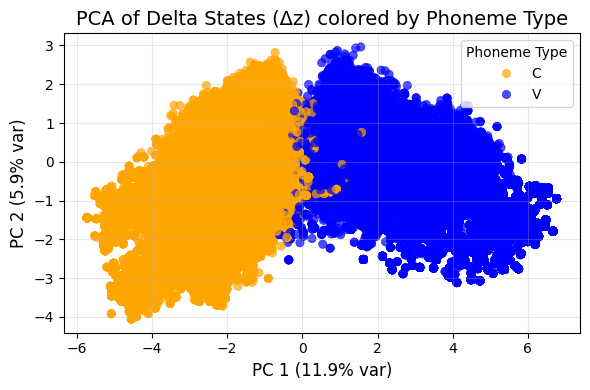

In [237]:
# pca of delta state color by type exclude eos
#plot
# exclude <EOS> from the plot
mask = train_ds.metadata["phoneme_type"] != "<EOS>"
plt.figure(figsize=(6, 4))
# correct mask (train_ds uses 'EOS' not '<EOS>')
mask = train_ds.metadata["phoneme_type"] != "EOS"

sns.scatterplot(
    x=delta_state_pca[mask.values, 0],
    y=delta_state_pca[mask.values, 1],
    hue=train_ds.metadata.loc[mask, "phoneme_type"],
    palette={"C": "orange", "V": "blue"},
    alpha=0.7,
    edgecolor=None,
)
plt.title("PCA of Delta States (Δz) colored by Phoneme Type", fontsize=14)
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=12)
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title="Phoneme Type", loc='best')
plt.tight_layout()
# plt.savefig("plots/delta_state_pca_phoneme_type.png", bbox_inches="tight")
plt.show()

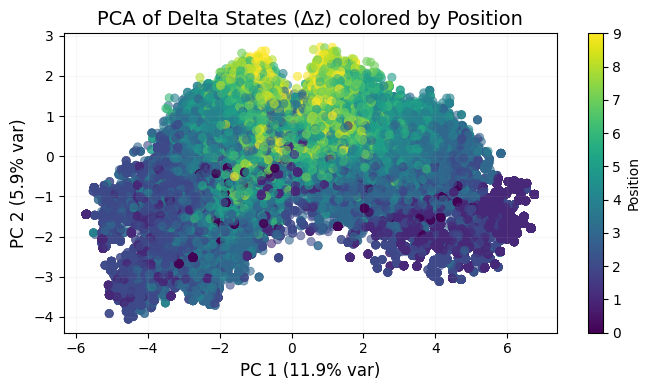

In [249]:
# pca of delta state color by position (viridis gradient) exclude eos
mask = (train_ds.metadata["phoneme_type"] != "EOS") & (train_ds.metadata["position"] < 10)  # limit for clarity

plt.figure(figsize=(7, 4))
plt.grid(alpha=0.1)
ax = sns.scatterplot(
    x=delta_state_pca[mask.values, 0],
    y=delta_state_pca[mask.values, 1],
    hue=train_ds.metadata.loc[mask, "position"],
    palette="viridis",
    alpha=0.6,
    edgecolor=None,
    legend=False  # Prevents Seaborn from creating the discrete legend box
)

# Extract typical matplotlib limits and bounds to build the colorbar correctly
norm = plt.Normalize(train_ds.metadata.loc[mask, "position"].min(), train_ds.metadata.loc[mask, "position"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# Draw colorbar
plt.colorbar(sm, ax=ax, label="Position")

plt.title("PCA of Delta States (Δz) colored by Position", fontsize=14)
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=12)
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=12)

plt.tight_layout()
plt.show()

/var/folders/ll/yd1jcjfx6bddqdh1n23q0j1m0000gn/T/ipykernel_77361/972997764.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Configuration", y="Result", palette=colors)


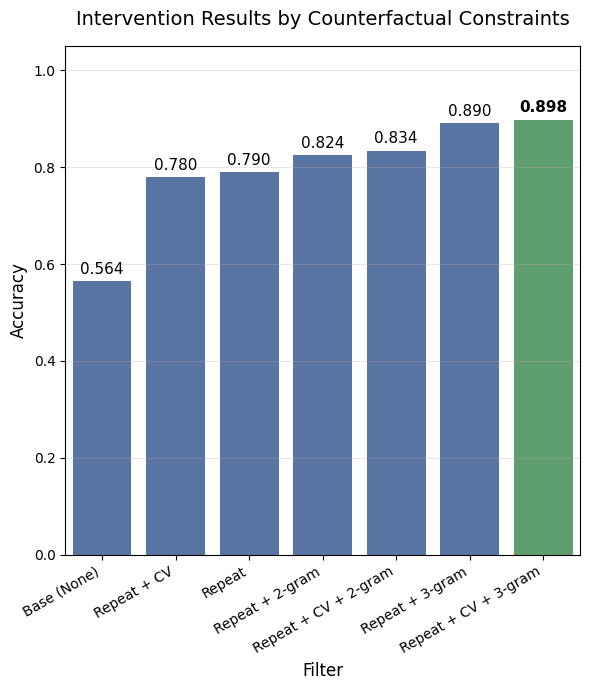

In [257]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Parse the LaTeX table into a DataFrame
data = [
    {"Repeat": False, "CV": False, "N-gram": "None", "Result": 0.564},
    {"Repeat": True,  "CV": True,  "N-gram": "None", "Result": 0.780},
    {"Repeat": True,  "CV": False, "N-gram": "None", "Result": 0.790},
    {"Repeat": True,  "CV": False, "N-gram": "2",    "Result": 0.824},
    {"Repeat": True,  "CV": True,  "N-gram": "2",    "Result": 0.834},
    {"Repeat": True,  "CV": False, "N-gram": "3",    "Result": 0.890},
    {"Repeat": True,  "CV": True,  "N-gram": "3",    "Result": 0.898},
]
df = pd.DataFrame(data)

# 2. Create readable labels for each configuration
def make_label(row):
    parts = []
    if row["Repeat"]: parts.append("Repeat")
    if row["CV"]: parts.append("CV")
    if row["N-gram"] != "None": parts.append(f"{row['N-gram']}-gram")
    
    if not parts:
        return "Base (None)"
    return " + ".join(parts)

df["Configuration"] = df.apply(make_label, axis=1)

# Sort by result for a cleaner progressing timeline
df = df.sort_values("Result", ascending=True).reset_index(drop=True)

# 3. Create the Bar Plot
plt.figure(figsize=(6, 7))

# Highlight the best performing setup with a different color palette
# Using a custom color list to make the highest value stand out
colors = ["#4C72B0"] * (len(df) - 1) + ["#55A868"]  # standard blue, highlighting the top in green
ax = sns.barplot(data=df, x="Configuration", y="Result", palette=colors)

# Annotate each bar with the exact score
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    # Bold the font if it's the maximum value
    font_weight = 'bold' if i == len(df)-1 else 'normal'
    ax.annotate(f"{height:.3f}", 
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=11, fontweight=font_weight,
                xytext=(0, 3), textcoords='offset points')

plt.title("Intervention Results by Counterfactual Constraints", fontsize=14, pad=15)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Filter", fontsize=12)
plt.ylim(0, 1.05) # Add headroom for annotations

# Rotate labels slightly for readability
plt.xticks(rotation=30, ha="right")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Run the plot
plt.show()